###Part 1 Importing the Data
This section includes an import from kaggle and only needs to be run the first time.  After the import, I save the data in a new dataframe called songdata.csv

In [1]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

In [3]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/million-song-dataset-spotify-lastfm


In [4]:
#display the contents of the million-song-dataset directory
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/million-song-dataset-spotify-lastfm/Music Info.csv
/kaggle/input/million-song-dataset-spotify-lastfm/User Listening History.csv
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRKSBDU128F92F888A.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRKYABN128F145EADB.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRXULGF12903CBE705.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRUMWIN128E0789F0F.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRSCACG12903CF0E7B.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRFFHMM128F422CA3F.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRAEHXB128F422EF3E.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRSVNKP128F428CB99.mp3
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/Metal-TRLDIJZ1

In [5]:
import pandas as pd
import os

# Correcting the file path to the 'Music Info.csv' file within the downloaded dataset
csv_file_path = os.path.join(path, 'Music Info.csv')

# Load the CSV file into a Pandas DataFrame
music_info_df = pd.read_csv(csv_file_path)

# Display the DataFrame
display(music_info_df.head())

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


###Part 2 Data Cleansing and NaNs
In this section, I review the data from Kaggle and clean up any NaNs

In [6]:
#values in the genre column
print(music_info_df['genre'].unique())

[nan 'RnB' 'Rock' 'Pop' 'Metal' 'Electronic' 'Jazz' 'Punk' 'Country'
 'Folk' 'Reggae' 'Rap' 'Blues' 'New Age' 'Latin' 'World']


In [7]:
#nans in the genre column
print(music_info_df['genre'].isna().sum())

28335


In [8]:
#what are the values for the tags feature
print(music_info_df['tags'].unique())

['rock, alternative, indie, alternative_rock, indie_rock, 00s'
 'rock, alternative, indie, pop, alternative_rock, british, 90s, love, britpop'
 'rock, alternative, alternative_rock, 90s, grunge' ...
 'rock, instrumental, japanese' 'electronic, indie_pop, love'
 'rock, alternative_rock, japanese, cover']


In [9]:
#Nans in the dataframe
print(music_info_df.isna().sum())

track_id                   0
name                       0
artist                     0
spotify_preview_url        0
spotify_id                 0
tags                    1127
genre                  28335
year                       0
duration_ms                0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
time_signature             0
dtype: int64


In [10]:
#what are the tags distribution
print(music_info_df['tags'].value_counts())

tags
country                                       506
reggae                                        454
black_metal                                   442
rap, hip_hop                                  378
drum_and_bass                                 365
                                             ... 
electronic, metalcore, japanese                 1
electronic, industrial, metalcore               1
experimental, hardcore                          1
metal, death_metal, heavy_metal, metalcore      1
metal, punk, hardcore, metalcore, screamo       1
Name: count, Length: 20057, dtype: int64


In [11]:
#drop Nans from the genre column
music_info_df = music_info_df.dropna(subset=['genre'])
music_info_df = music_info_df.dropna(subset=['tags'])
music_info_df=music_info_df.reset_index(drop=True)

#check Nans again
print(music_info_df.isna().sum())

track_id               0
name                   0
artist                 0
spotify_preview_url    0
spotify_id             0
tags                   0
genre                  0
year                   0
duration_ms            0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
dtype: int64


In [12]:
#drop columns i no longer need including track_id, name, artist, spotify_preview_url, spotify_id
music_info_df = music_info_df.drop(columns=['tags','track_id', 'name', 'artist', 'spotify_preview_url',
                                            'spotify_id'])

In [13]:
#create a new dataframe called songdata
songdata = music_info_df


In [ ]:
#save a local copy of songdata
songdata.to_csv('songdata.csv', index=False)


In [ ]:
#what are the column types
print(songdata.dtypes)

genre                object
year                  int64
duration_ms           int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object


###Part 3 Data Analysis and Visualization
In this section I review data types, visualize data for better understanding.  I import all libraries again so i can start here for future reviews.

In [ ]:
#reload all libraries
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# a reload of the  dataframe
import pandas as pd
songdata=pd.read_csv('songdata.csv')

In [ ]:
#create X and y
X=songdata.drop(columns=['genre', 'tags',
                         'year'])
y=songdata['genre']

In [ ]:
#apply standardscaler to x
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
#format y data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
songdata['genre_encoded'] = y

##Part 3A Visualizing the Data

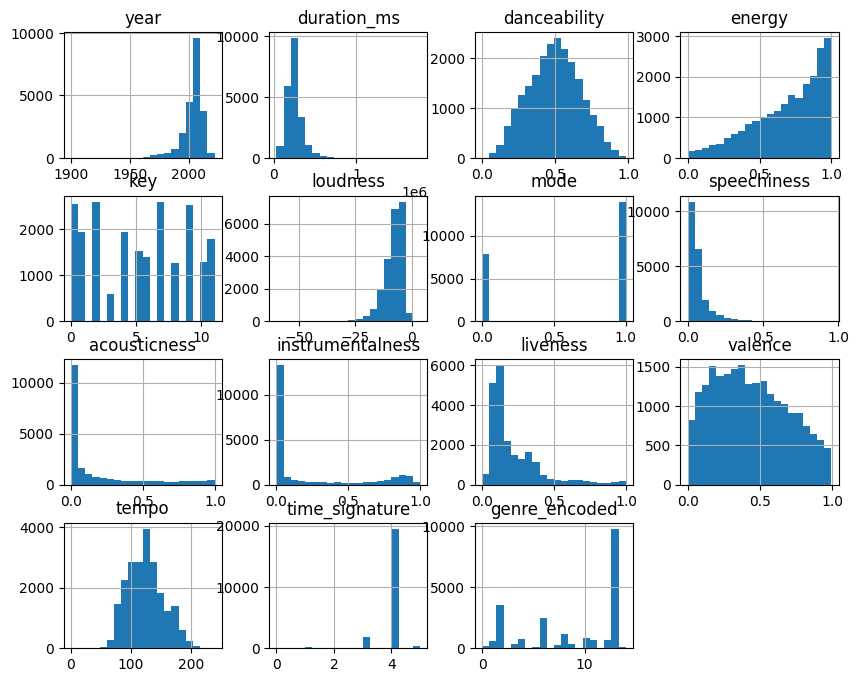

In [ ]:
# Histogram/Barplots for numerical variables
songdata.hist(bins=20, figsize=(10, 8))
plt.show()

In [ ]:
# Step 1: Prepare data for plotting
# Create a DataFrame from the scaled features, preserving original column names for clarity
X_df = pd.DataFrame(X, columns=songdata.drop(columns=['genre']).columns)

# Add the original 'genre' column to the new DataFrame
X_df['genre'] = songdata['genre']

# Display the first few rows of the new DataFrame
display(X_df.head())

,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre
0,-1.469507,-0.315548,0.069384,0.536099,-0.360871,0.537530,-1.328299,-0.462858,-0.682213,-0.670165,-0.700696,0.409687,-0.142449,0.236811,RnB
1,0.518702,-0.125193,0.109059,-1.103277,0.479453,-0.406794,0.752842,-0.502161,-0.647182,-0.671107,-0.476199,-1.310201,-1.089931,0.236811,RnB
2,0.401749,0.573423,0.398121,-1.107417,-0.080763,0.072873,0.752842,-0.663178,1.815678,-0.671482,-0.525240,-1.039877,0.743887,0.236811,Rock
3,-0.066065,0.134141,0.330107,-0.854887,-0.360871,0.022837,0.752842,-0.390591,-0.624119,-0.669943,-0.438056,0.292155,-1.344400,0.236811,Pop
4,0.752609,-0.275141,1.775416,0.097276,0.199345,0.084245,0.752842,0.754275,-0.565063,-0.667348,3.321727,1.541914,0.481245,0.236811,RnB


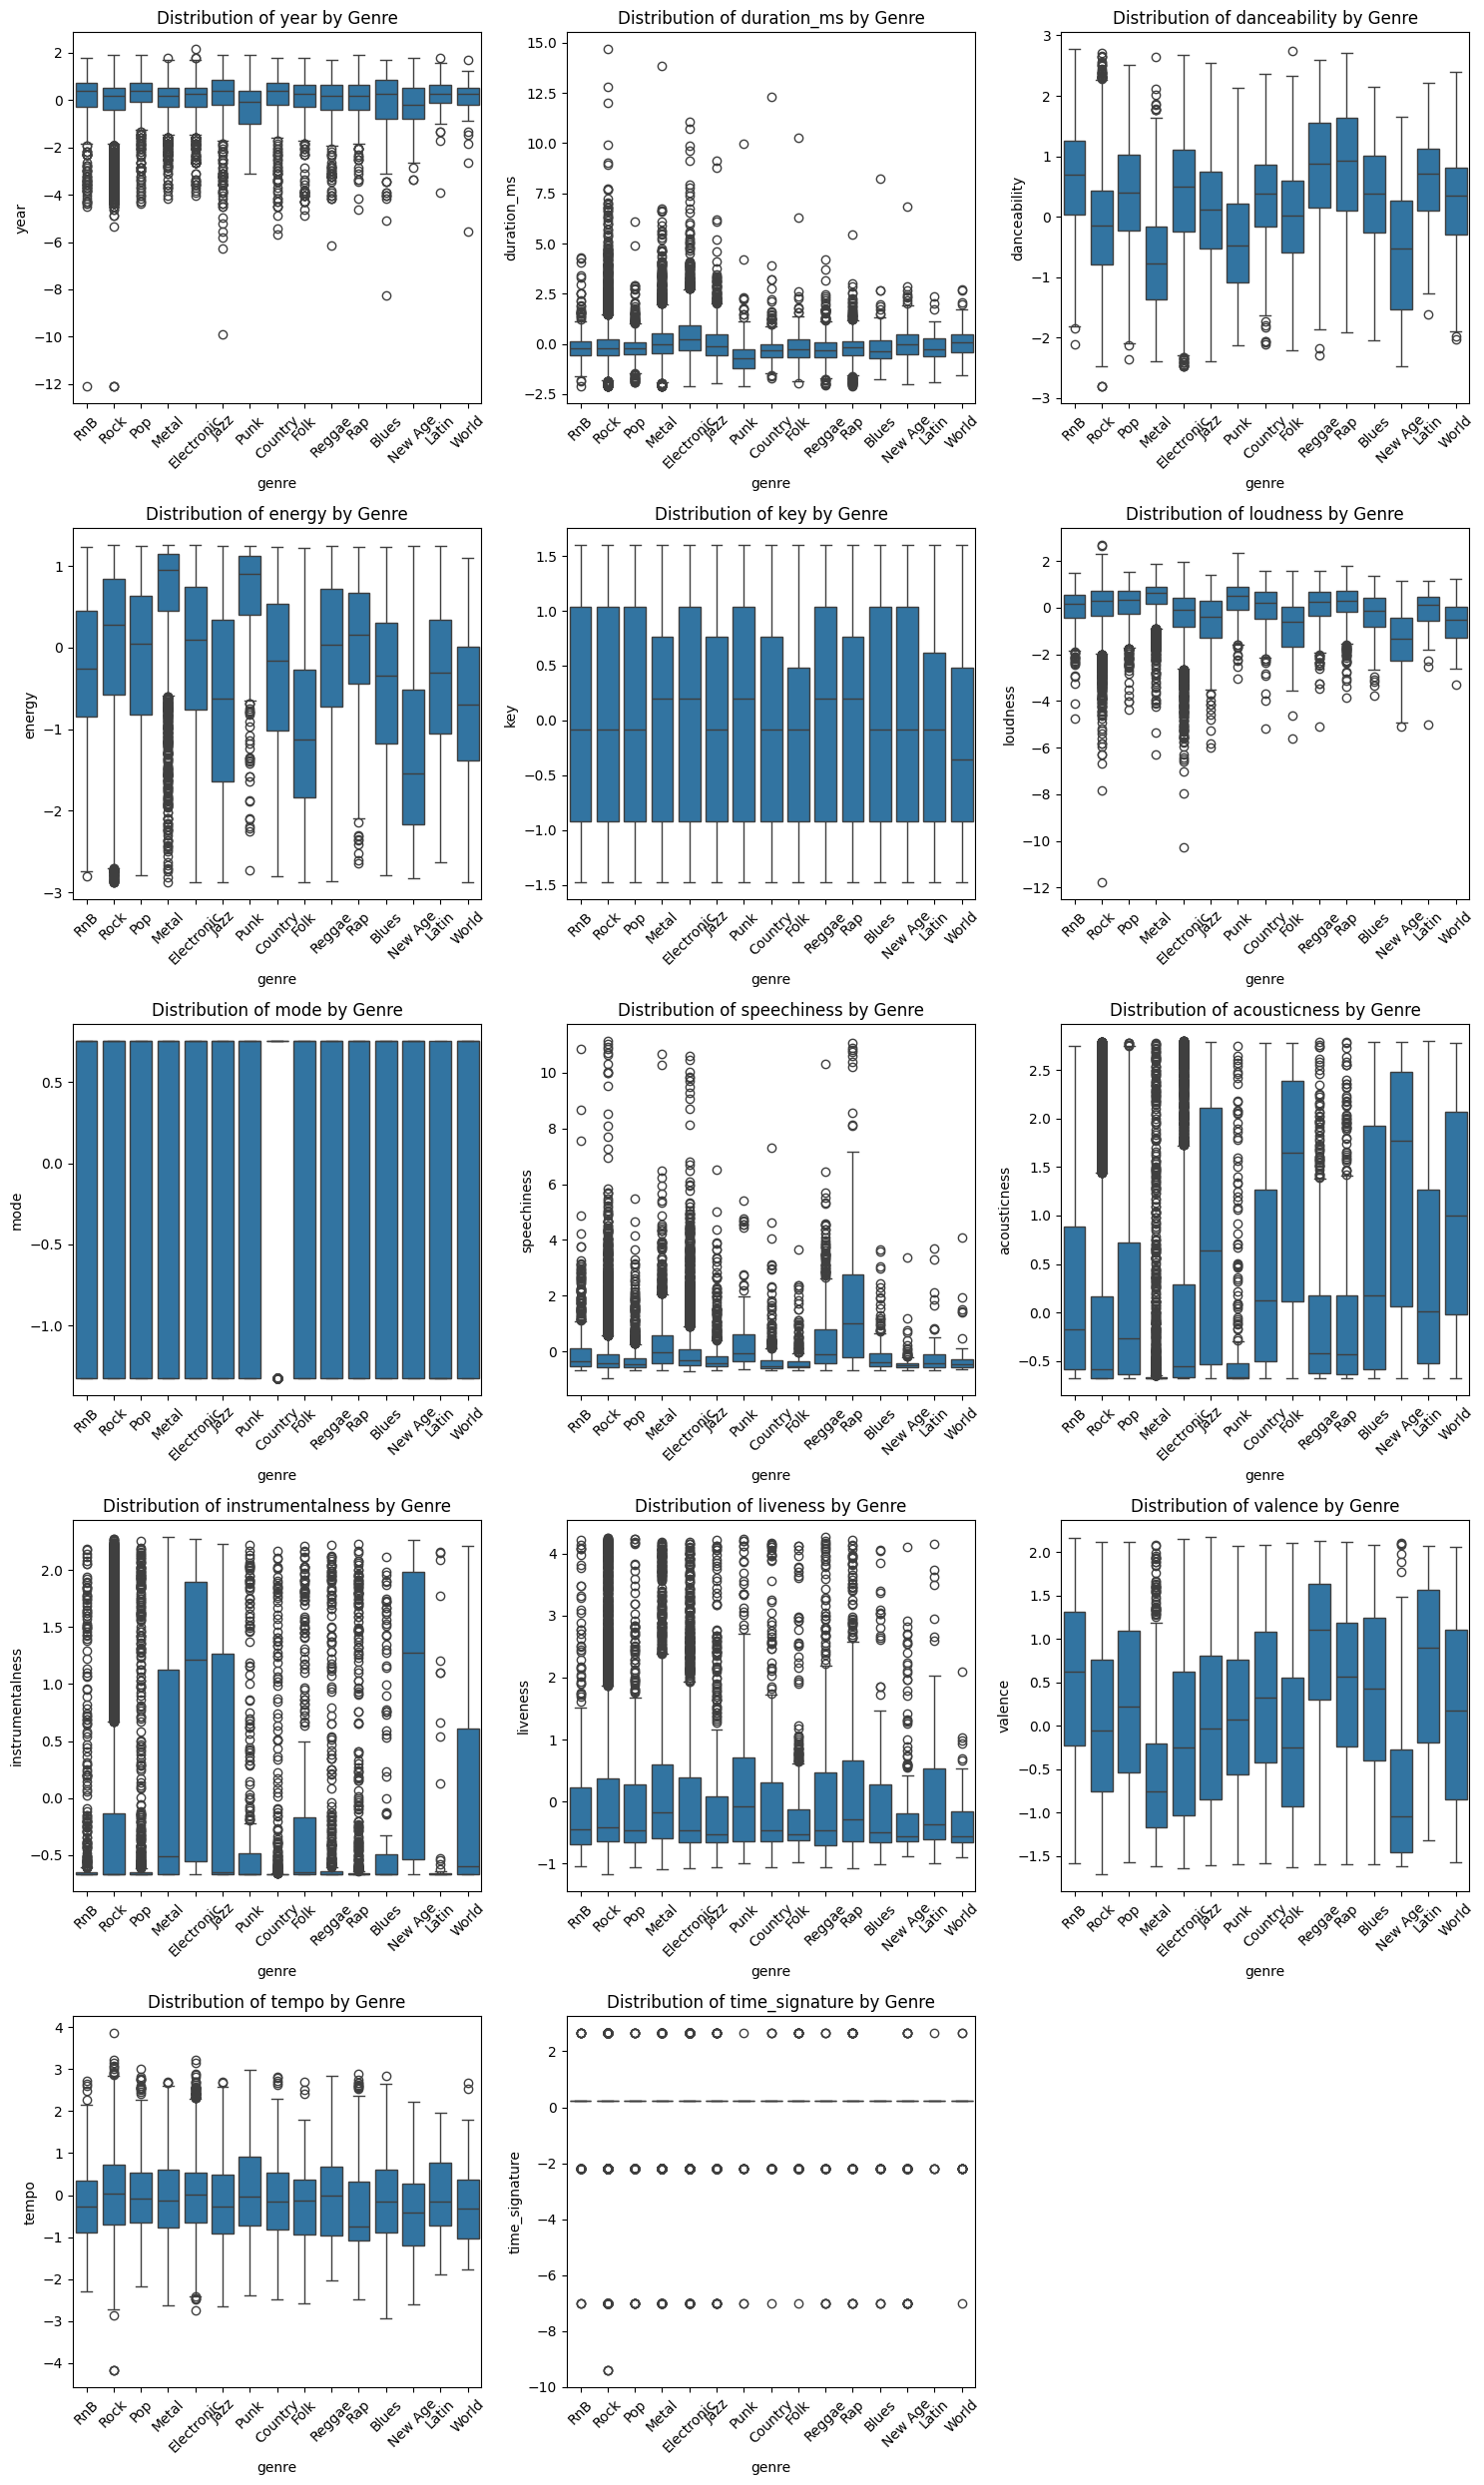

In [ ]:
# Step 2: Iterate and plot feature distributions per genre
import matplotlib.pyplot as plt

# Get the list of feature columns (excluding the 'genre' column)
feature_columns = X_df.columns.drop('genre')

# Determine the number of rows and columns for the subplots
n_features = len(feature_columns)
n_cols = 3  # You can adjust the number of columns as needed
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

# Iterate through each feature and create a box plot
for i, col in enumerate(feature_columns):
    sns.boxplot(x='genre', y=col, data=X_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Genre')
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

###Part 4 Feature Engineering

In [ ]:
# Calculate the correlation of each feature with the target variable y
# Select numerical columns, drop 'year' and 'genre_encoded', then calculate correlation with 'genre_encoded' Series
numerical_features = songdata.select_dtypes(include=np.number).drop(columns=['year', 'genre_encoded'])
feature_correlation_with_y = numerical_features.corrwith(songdata['genre_encoded'])

# Display the correlation of each feature with y
print("Correlation of features with genre_encoded:")
print(feature_correlation_with_y)

Correlation of features with genre_encoded:
duration_ms        -0.127678
danceability       -0.097004
energy              0.063302
key                -0.011273
loudness            0.138843
mode                0.061356
speechiness        -0.036797
acousticness       -0.085451
instrumentalness   -0.269725
liveness            0.000572
valence             0.098733
tempo               0.031346
time_signature      0.003986
dtype: float64


Based on this information, the most important features to include are Instrumentalness, loudness, duration.  I can also include valence and danceability

##Part 4a Polynomial features
In this section polynomials of the most important features are added to see if it improves correlation with the genre.  As you will see, polynomial features did not improve correlation.

In [ ]:
#correlation between polynomials for instrumentalness, loudness, duration, valence and danceability with genre encoded
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)


In [ ]:
#create and add columns to songdata of these polynomialfeatures
# Get the names of the numerical columns used for fitting poly
numerical_cols_for_poly = songdata.select_dtypes(include=np.number).drop(columns=['year', 'genre_encoded']).columns

poly_features = poly.get_feature_names_out(input_features=numerical_cols_for_poly)

# Ensure the number of polynomial features matches the number of columns in X_poly
if len(poly_features) != X_poly.shape[1]:
    print(f"Warning: Number of generated polynomial feature names ({len(poly_features)}) does not match the number of columns in X_poly ({X_poly.shape[1]}). Proceeding, but results may be unexpected.")

# Create a DataFrame from X_poly with the generated feature names
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

# Add the polynomial features to the songdata DataFrame.
# We need to be careful not to overwrite existing columns or create duplicates.
# A safer approach is to concatenate the original songdata (excluding the columns used for poly)
# with the new polynomial features DataFrame and the 'genre_encoded' column.

# Select the original columns from songdata that were not used to create polynomial features
original_cols_to_keep = songdata.drop(columns=numerical_cols_for_poly).columns

# Concatenate the relevant original columns, the polynomial features, and the target variable
songdata = pd.concat([songdata[original_cols_to_keep], X_poly_df, songdata['genre_encoded']], axis=1)

# Display the head of the modified songdata DataFrame to verify
display(songdata.head())

,tags,genre,year,genre_encoded,1,duration_ms,danceability,energy,key,loudness,...,valence^2 tempo,valence^2 time_signature,valence tempo^2,valence tempo time_signature,valence time_signature^2,tempo^3,tempo^2 time_signature,tempo time_signature^2,time_signature^3,genre_encoded
0,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,12,1.0,-0.315548,0.069384,0.536099,-0.360871,0.537530,...,-0.023909,0.039747,0.008313,-0.013820,0.022975,-0.002891,0.004805,-0.007988,0.01328,12
1,"rock, alternative, indie, alternative_rock, in...",RnB,2008,12,1.0,-0.125193,0.109059,-1.103277,0.479453,-0.406794,...,-1.871005,0.406516,-1.556453,0.338173,-0.073475,-1.294783,0.281319,-0.061123,0.01328,12
2,"rock, alternative, indie, pop, alternative_roc...",Rock,2007,13,1.0,0.573423,0.398121,-1.107417,-0.080763,0.072873,...,0.804398,0.256074,-0.575434,-0.183185,-0.058316,0.411643,0.131043,0.041717,0.01328,13
3,"rock, alternative, alternative_rock, 90s, funk",Pop,2003,8,1.0,0.134141,0.330107,-0.854887,-0.360871,0.022837,...,-0.114751,0.020213,0.528044,-0.093013,0.016384,-2.429884,0.428014,-0.075393,0.01328,8
4,"rock, electronic, alternative, indie, pop, alt...",RnB,2010,12,1.0,-0.275141,1.775416,0.097276,0.199345,0.084245,...,1.144160,0.563018,0.357103,0.175723,0.086470,0.111455,0.054845,0.026988,0.01328,12


In [ ]:
# Calculate the correlation of the polynomial features with the target variable y (genre_encoded)
# Use X_poly_df which contains the polynomial features with correct names and indices, and y for the target
# Create a temporary DataFrame for correlation from X_poly_df and y, ensuring index alignment

# Drop the constant term '1' from X_poly_df if it exists
X_poly_df_no_constant = X_poly_df.drop(columns=['1'], errors='ignore')

# Create a temporary DataFrame with aligned indices for polynomial features and y
# Use the index from X_poly_df as it should be aligned with the original songdata index and y
poly_features_and_target_df = X_poly_df_no_constant.copy()
poly_features_and_target_df['genre_encoded'] = pd.Series(y, index=poly_features_and_target_df.index)


# Calculate the correlation of polynomial features with genre_encoded
polynomial_correlation_with_y = poly_features_and_target_df.corr()['genre_encoded'].drop('genre_encoded', errors='ignore')


# Display the correlation of polynomial features with y
print("Correlation of polynomial features with genre_encoded:")
print(polynomial_correlation_with_y)

Correlation of polynomial features with genre_encoded:
duration_ms                -0.127678
danceability               -0.097004
energy                      0.063302
key                        -0.011273
loudness                    0.138843
                              ...   
valence time_signature^2    0.020176
tempo^3                     0.026640
tempo^2 time_signature     -0.006612
tempo time_signature^2      0.000628
time_signature^3            0.011721
Name: genre_encoded, Length: 559, dtype: float64


In [ ]:
#sort correlations from highest to lowest
polynomial_correlation_with_y.sort_values(ascending=True)

#show only correlations with y
polynomial_correlation_with_y[polynomial_correlation_with_y != 1.0]

,genre_encoded
duration_ms,-0.127678
danceability,-0.097004
energy,0.063302
key,-0.011273
loudness,0.138843
...,...
valence time_signature^2,0.020176
tempo^3,0.026640
tempo^2 time_signature,-0.006612
tempo time_signature^2,0.000628


In [ ]:
#sort by the absolute value
polynomial_correlation_with_y.abs().sort_values(ascending=False)

,genre_encoded
instrumentalness,0.269725
instrumentalness^3,0.255021
mode^2 instrumentalness,0.248583
instrumentalness^2,0.247739
key^2 instrumentalness,0.219678
...,...
key^2 liveness,0.000254
loudness speechiness tempo,0.000189
key liveness valence,0.000161
speechiness^2 acousticness,0.000150


In [ ]:
#display correlations for instrumentalness, loudness and duration and for the squared and 3 polynomial factors
selected_features = ['instrumentalness', 'instrumentalness^2', 'instrumentalness^3',
                     'loudness', 'loudness^2', 'loudness^3',
                     'duration_ms', 'duration_ms^2', 'duration_ms^3']

print(polynomial_correlation_with_y[selected_features])

instrumentalness     -0.269725
instrumentalness^2   -0.247739
instrumentalness^3   -0.255021
loudness              0.138843
loudness^2           -0.079648
loudness^3            0.053234
duration_ms          -0.127678
duration_ms^2        -0.043094
duration_ms^3        -0.017469
Name: genre_encoded, dtype: float64


##Part 5: Prepare a Baseline Model


In [ ]:
#create training and test data set for all features
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#create training and test data set for only instrumentalness, loudness and duration
# Get the original numerical column names (before scaling and splitting)
original_numerical_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
                           'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
                           'tempo', 'time_signature']

# Convert X_train and X_test back to DataFrames with original column names
X_train_df = pd.DataFrame(X_train, columns=original_numerical_cols)
X_test_df = pd.DataFrame(X_test, columns=original_numerical_cols)

# Select the desired columns by name
X_train_selected = X_train_df[['instrumentalness', 'loudness', 'duration_ms']]
X_test_selected = X_test_df[['instrumentalness', 'loudness', 'duration_ms']]


In [ ]:
#create a training and test data set for instrumentalness, loudness, duration,vvalence and danceability
X_train_selected_five = X_train_df[['instrumentalness', 'loudness', 'duration_ms', 'valence', 'danceability']]
X_test_selected_five = X_test_df[['instrumentalness', 'loudness', 'duration_ms', 'valence', 'danceability']]

##Part 5a: Setting a baseline
Below we create two baseline models one with DummyClassifier identifying the most frequent genre and the second using linear regression on all features

In [ ]:
#create baseline model to beat
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)


0.44867700729927007

Since DummyClassifier is based on the most frequent class from y_train, it doesn't make sense to fit it with the smaller featured datasets

In [ ]:
#a second baseline using logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.5241788321167883


In [ ]:
#logistic regression with three features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg = LogisticRegression()
logreg.fit(X_train_selected, y_train)
y_pred = logreg.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.48038321167883213


In [ ]:
#logistic regression with five features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg = LogisticRegression()
logreg.fit(X_train_selected_five, y_train)
y_pred = logreg.predict(X_test_selected_five)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5031934306569343


##Part 5b PCA Components
This section applies PCA to features for comparison to selecting specific features

In [ ]:
#create a dataset using PCA to run through models
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


pca=PCA(n_components=0.95)
pca.fit(X_train)
X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print(pca.explained_variance_ratio_)

[0.2092333  0.13266129 0.09564139 0.08652661 0.07774254 0.07089189
 0.06907171 0.06354388 0.06211017 0.05901276 0.0313013 ]


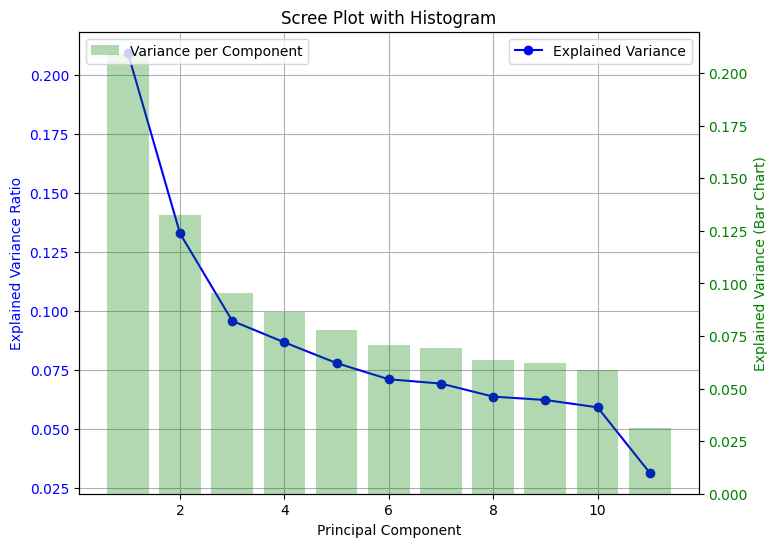

In [ ]:
# Explained variance
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Scree plot (line plot)
ax1.plot(components, explained_variance, marker='o', linestyle='-', color='b', label="Explained Variance")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio", color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title("Scree Plot with Histogram")
ax1.grid(True)

# Create second y-axis for Histogram
ax2 = ax1.twinx()
ax2.bar(components, explained_variance, alpha=0.3, color='g', label="Variance per Component")
ax2.set_ylabel("Explained Variance (Bar Chart)", color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Show legend
ax1.legend(loc="upper right")
ax2.legend(loc="upper left")

# Display plot
plt.show()

In [ ]:
#check variable weights
print(pca.components_)

[[-0.07643115  0.05503433  0.53834864  0.0269911   0.52427049  0.00281041
   0.14532228 -0.47679286 -0.23119066  0.11758532  0.22971611  0.1991298
   0.13253935]
 [-0.31912437  0.59214709 -0.17692009  0.00778417 -0.07163066  0.06168916
  -0.01872727  0.16516558 -0.27084952 -0.20708036  0.55861919 -0.15717602
   0.16306998]
 [-0.36482758 -0.24310546 -0.03566637 -0.52400442  0.02602217  0.61137696
   0.03315408  0.12216653 -0.27946124  0.12984715 -0.06279879  0.08285632
  -0.18893736]
 [-0.41519089 -0.11171112 -0.04620476  0.400665   -0.05628927 -0.29239197
   0.47582747  0.19117312 -0.22368442  0.39186511 -0.03848451 -0.03727849
  -0.30722241]
 [ 0.2086552   0.16968769  0.0215417  -0.23469864 -0.07284894  0.10432382
   0.28190736 -0.02112891  0.11944061  0.58732604 -0.03977167 -0.49559929
   0.41181864]
 [ 0.06480226  0.15477105 -0.03731425 -0.14573603 -0.22744144  0.07412478
   0.51390514  0.06903963  0.37785542  0.00551553  0.16190705  0.6643757
   0.11274789]
 [-0.27746681 -0.2657855

In [ ]:
#use DummyClassifier with PCA
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_pca, y_train)
dummy_clf.score(X_test_pca, y_test)


0.44867700729927007

In [ ]:
#use LogisticRegression with PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)
y_pred = logreg.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5175638686131386


#LogisticRegression performed best using all of the features rather than a subset of features

###Part 6 Improve the Model
This section will focus on identifying the best model and model parameters for the data.  Since X includes only numeric data, the models will include LinearRegression, KNNNeighbors, DecisionTree and SVC. The Accuracy score to beat is 52.4%

In [ ]:
#check if polynomials help for any of the features

In [ ]:
#set up logistic regression and other models for analysis based on the data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=1000), {'logisticregression__C': [0.1, 1, 10]}),
    'svc': (SVC(), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'poly', 'rbf']}),
    'decisiontreeclassifier': (DecisionTreeClassifier(), {'decisiontreeclassifier__max_depth': [5, 10, 15]})
}

In [ ]:
#create the pipeline for models identified above
#conduct a gridsearch for each model, fit the data to the model, capture time, and provide
#metrics for results and parameters in a table

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import time

results = []
for name, (model, params) in models.items():
    pipeline = Pipeline([
        (name, model)
    ])

    #perform gridsearch
    start_time = time.time()
    grid_search = GridSearchCV(pipeline, params, cv=6)
    # Fit the grid search with the pca data
    grid_search.fit(X_train, y_train)
    # Recalculate fit_time based on the new grid search results
    fit_time = (time.time() - start_time) / grid_search.n_splits_

    #get the best model
    best_model = grid_search.best_estimator_

    #evaluate the model on training and test sets
    # Use the best_model (the fitted pipeline) with the original data for scoring
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    best_params = grid_search.best_params_

    #append the results in a dataframe
    results.append([name, train_score, test_score, fit_time, best_params])

In [ ]:
#create results dataframe
results_df = pd.DataFrame(results, columns=['name', 'train score', 'test score', 'average fit time', 'best_params'])
results_df.set_index('name', inplace=True)
results_df.sort_values(by='test score', ascending=False, inplace=True)
results_df

,train score,test score,average fit time,best_params
name,,,,
svc,0.557666,0.534215,303.616811,"{'svc__C': 1, 'svc__kernel': 'rbf'}"
logisticregression,0.519507,0.527600,5.866864,{'logisticregression__C': 0.1}
decisiontreeclassifier,0.522644,0.523038,0.778287,{'decisiontreeclassifier__max_depth': 5}
knn,0.584645,0.483120,3.766416,{'knn__n_neighbors': 7}


In [ ]:
#use svc model with svc_C=1, svc_kernel= 'rbf'
from sklearn.svm import SVC
best_model = SVC(C=1, kernel='rbf')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

###Part 7 Apply Ensemble Techniques to Improve the Model

In [ ]:
#create a bagging classifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
bagging_clf = BaggingClassifier(estimator=best_model, n_estimators=10, random_state=42, bootstrap=False)
bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5280565693430657


In [ ]:
#try bagging with Decisiontreeclassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

best_model = DecisionTreeClassifier(max_depth=5)
bagging_clf = BaggingClassifier(estimator=best_model, n_estimators=10, random_state=42)
bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5285127737226277


In [ ]:
#best parameters for n_estimators
n_trees = [1500, 2000, 2250]
oob_scores = []
for n in n_trees:
    model = BaggingClassifier(estimator=best_model, n_estimators=n, random_state=42, oob_score=True).fit(X_train, y_train)
    oob_scores.append(model.oob_score_)
    pass

### ANSWER CHECK
print(oob_scores)

[0.5220739219712526, 0.5225872689938398, 0.5224161533196441]


In [ ]:
#apply RandomForest to best_model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_clf = RandomForestClassifier(n_estimators=2000, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5453923357664233


In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_trees = [1500, 2000, 2250]
oob_scores = []
for n in n_trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True).fit(X_train, y_train)
    oob_scores.append(model.oob_score_)
    pass

### ANSWER CHECK
print(oob_scores)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
depths = [9, 10, 11, 12, 15, None]
oob_scores = []
for d in depths:
    model = RandomForestClassifier(random_state=42, oob_score=True, max_depth=d).fit(X_train, y_train)
    oob_scores.append(model.oob_score_)
    pass

### ANSWER CHECK
print(oob_scores)
#15 is the best depth

[0.5366757928359571, 0.5393566050650239, 0.5410677618069816, 0.5410107232489163, 0.5423226100844171, 0.5375313712069358]


In [ ]:
#RandomClassifier with max_depth=15J and n_estimators = 2000
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_clf = RandomForestClassifier(n_estimators=2000, random_state=42, max_depth=15)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5453923357664233
